# Phase 1: Data Preparation

In this phase, we begin by installing the required packages to work with the data:
- `jsonlite` for reading JSON files
- `dplyr` for data manipulation
- `ggplot2` for visualization

We then load and extract the relevant data, carefully examining its structure to understand the variables and their formats.

Next, we convert the timestamp column to a proper Date format, followed by cleaning and formatting the dataframe to ensure consistency.

Basic validation is performed by checking for missing values and duplicated dates, ensuring the data is ready for analysis.

Finally, we generate an initial visualization to gain a quick overview of the dataset.

In [21]:
install.packages("jsonlite")
install.packages("dplyr")
install.packages("ggplot2")

Warning message:
"package 'jsonlite' is in use and will not be installed"
Warning message:
"package 'dplyr' is in use and will not be installed"
Warning message:
"package 'ggplot2' is in use and will not be installed"


In [22]:
library(jsonlite)
library(dplyr)
library(ggplot2)

In [23]:
options(repr.plot.width = 12, repr.plot.height = 6)

In [24]:
raw_data <- fromJSON("n-transactions.json")
transactions_data <- raw_data$`n-transactions`
str(transactions_data)
head(transactions_data)

'data.frame':	1567 obs. of  2 variables:
 $ x: num  1.23e+12 1.23e+12 1.23e+12 1.23e+12 1.23e+12 ...
 $ y: int  109 105 192 122 129 122 120 136 118 125 ...


,x,y
,<dbl>,<int>
1,1.232150e+12,109
2,1.232496e+12,105
3,1.232842e+12,192
4,1.233187e+12,122
5,1.233533e+12,129
6,1.233878e+12,122


In [29]:
# x is the date in milliseconds, we need to convert it to a date format
transactions_data <- transactions_data %>% mutate(date = as.POSIXct(x / 1000, origin = "1970-01-01", tz='UTC'))
# creating the dataframe we will work with
df <- transactions_data %>% select(date, transactions=y)
# sorting df
df <- df %>% arrange(date)

head(df)
tail(df)

,date,transactions
,<dttm>,<int>
1,2009-01-17,109
2,2009-01-21,105
3,2009-01-25,192
4,2009-01-29,122
5,2009-02-02,129
6,2009-02-06,122


,date,transactions
,<dttm>,<int>
1562,2026-02-24,566873
1563,2026-02-28,424909
1564,2026-03-04,377812
1565,2026-03-08,453532
1566,2026-03-12,449282
1567,2026-03-16,405364


In [26]:
# checking for missing values
sum(is.na(df))
# checking for duplicate dates
sum(duplicated(df$date))

[1] 0

[1] 0

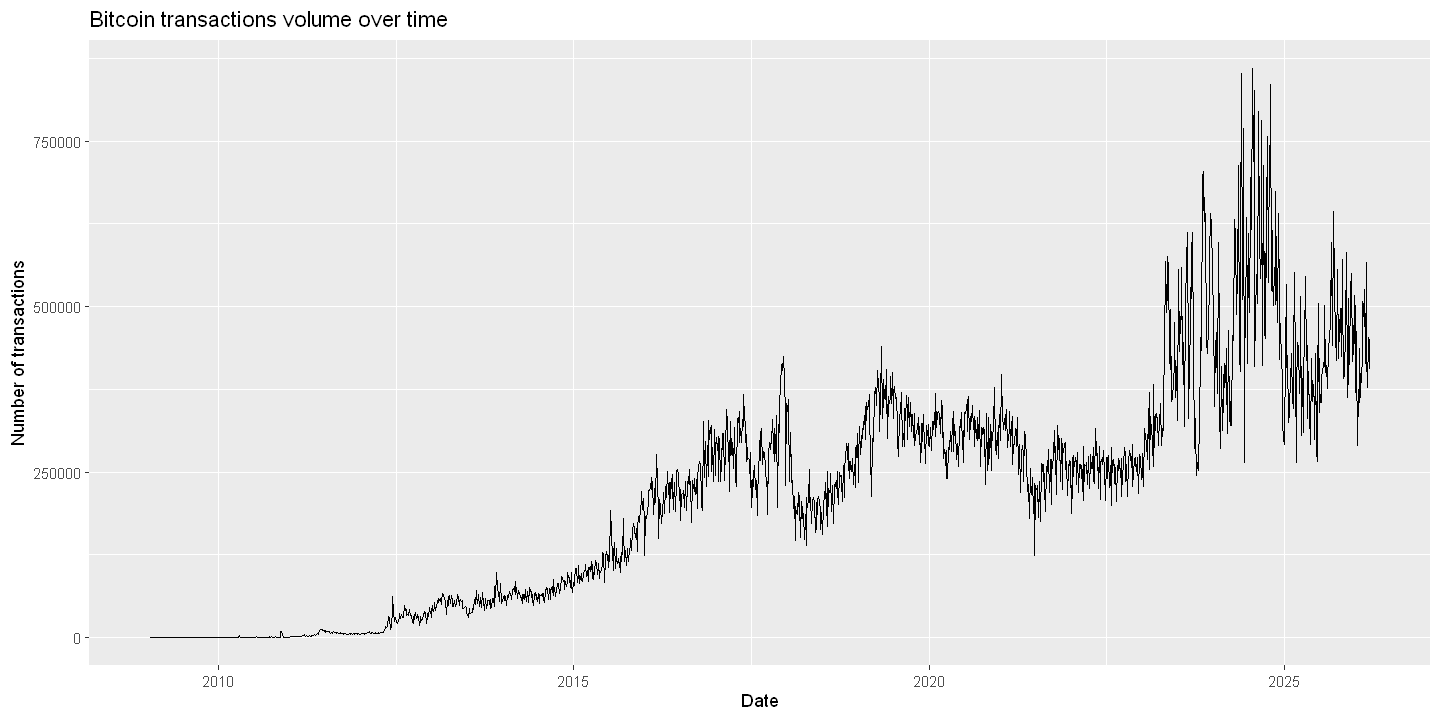

In [27]:
ggplot(df, aes(x = date, y = transactions)) + 
  geom_line() + 
  labs(title = "Bitcoin transactions volume over time", x = "Date", y = "Number of transactions")

# Phase 1 Summary

The dataset contains **1,567 daily observations**, covering Bitcoin activity over a 17-year period from **January 17, 2009** to **March 16, 2026**.

Key findings from the data include:
- A clear upward trend in transaction volume over time
- Variability that increases significantly in later years

# Phase 2: Data Validation
In this phase, we validate data by checking for time gaps (very important for time series forecasting), we do this by creating a complete sequence of dates from the minimum to the maximum date in the dataset and then finding missing dates by comparing the full sequence with the dates in the dataset.

In [ ]:
full_dates <- data.frame(date = seq(min(df$date), max(df$date), by = "days"))

df$date <- as.Date(df$date)
full_dates$date <- as.Date(full_dates$date)

missing_dates <- full_dates %>%
  anti_join(df, by = "date")

nrow(missing_dates)
head(missing_dates)
# 4701 missing dates, which means data is not daily spaced, after further analysis it appears that data is 4-day spaced (next cell).

[1] 4701

,date
,<date>
1,2009-01-18
2,2009-01-19
3,2009-01-20
4,2009-01-22
5,2009-01-23
6,2009-01-24


In [ ]:
diff_days <- diff(df$date)
table(diff_days)
unique(diff(df$date))

diff_days
   4    7 
1565    1 

Time differences in days
[1] 4 7

# Phase 2 Summary:
- Dataset is regularly spaced at 4-day intervals
- No true missing values detected
- Time series is consistent and complete
- No interpolation required